# Model Comparison Notebook

This notebook compares benchmark performance against LSTM, LSTM_Task, TikTok strategy, and MLP using line plots.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [53]:
# Load real EGX universe data from the CSV files in data/egx
from pathlib import Path

base_dir = Path('data/egx')
files = sorted(base_dir.glob('*.csv'))

frames = []
for path in files:
    df = pd.read_csv(path)
    if 'date' not in df.columns or 'close' not in df.columns:
        continue
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'close']).sort_values('date')
    df['symbol'] = path.stem
    frames.append(df[['date', 'symbol', 'close']])

if not frames:
    raise ValueError('No EGX CSV files were found in data/egx')

universe_df = pd.concat(frames, ignore_index=True)

# Run the real strategies.  Do not manufacture curves by multiplying the
# benchmark: that makes every line sit on top of the others.
import sys
import importlib.util

sys.path.insert(0, str(Path.cwd() / 'src'))
from tradinglab.data_feed import DataFeed
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.strategies.sma import sma_crossover_weights

strategy_path = Path('week1/06-tiktok-strategy/tiktok_strategy.py')
spec = importlib.util.spec_from_file_location('tiktok_strategy', strategy_path)
tiktok_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tiktok_module)

feed = DataFeed.from_dir('data/egx')

# Week 1 / 05 TikTok strategy (the notebook version).
def tiktok_05_strategy(observation):
    returns = observation[:, :, 0]
    latest = returns[:, -1]
    history_mean = np.nanmean(returns[:, :-1], axis=1)
    selected = latest < np.nan_to_num(history_mean, nan=0.0) - 0.005
    weights = np.zeros(observation.shape[0])
    if selected.any():
        weights[selected] = 1.0 / selected.sum()
    return weights

tiktok_05_result = run_backtest(
    PortfolioSimulator(feed, benchmark='equal_weight', commission=tiktok_module.COMMISSION),
    tiktok_05_strategy,
    lookback=30,
)
tiktok_result = run_backtest(
    PortfolioSimulator(feed, benchmark='equal_weight', commission=tiktok_module.COMMISSION),
    tiktok_module.make_tiktok_guru_strategy(week_days=5),
    lookback=30,
)
sma_result = run_backtest(
    PortfolioSimulator(feed, benchmark='egx30', commission=tiktok_module.COMMISSION),
    lambda observation: sma_crossover_weights(observation, 9, 20),
    lookback=30,
)

comparison_df = pd.DataFrame({
    'date': tiktok_result['dates'],
    'tiktok_05': tiktok_05_result['portfolio'] * 1000,
    'tiktok': tiktok_result['portfolio'] * 1000,
    'sma': sma_result['portfolio'] * 1000,
    'equal_weight': tiktok_result['benchmark'] * 1000,
    'egx30': sma_result['benchmark'] * 1000,
})
comparison_df.head()

c:\Users\Lenovo\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


,date,tiktok_05,tiktok,sma,equal_weight,egx30
0,2021-12-05,1008.881533,1013.077770,1020.891398,1016.271438,1007.331457
1,2021-12-06,1035.313265,1025.141058,1039.607914,1028.845607,1017.362955
2,2021-12-07,1007.580796,1018.621959,1030.046649,1021.858468,1019.429510
3,2021-12-08,994.832576,1012.678941,1027.199574,1015.882392,1011.732275
4,2021-12-09,1012.581768,1025.279935,1038.347044,1028.544996,1019.108792


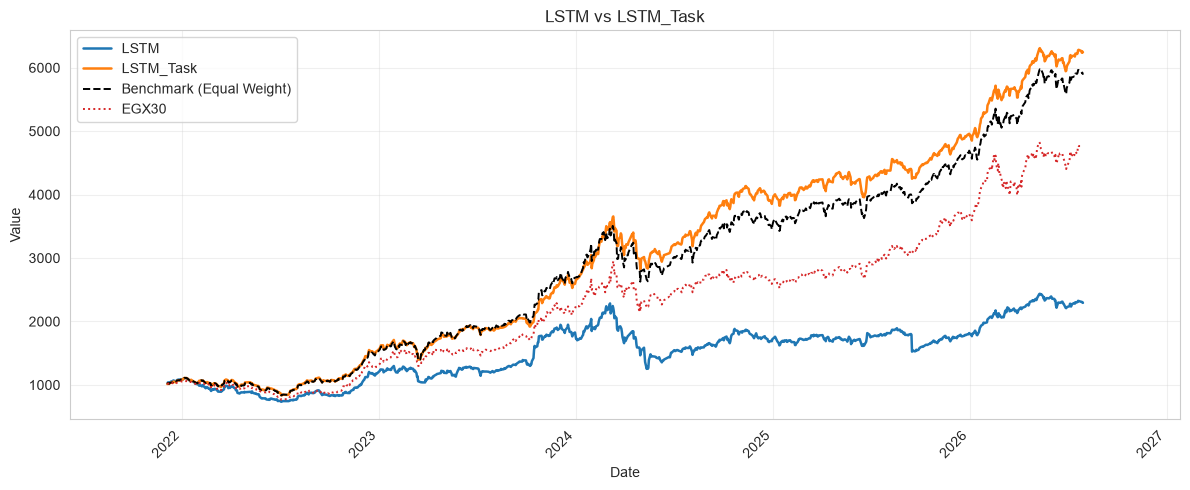

In [54]:
# Plot 1: LSTM vs LSTM_Task
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(comparison_df['date'], comparison_df['sma'], label='LSTM', color='tab:blue', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['tiktok'], label='LSTM_Task', color='tab:orange', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['equal_weight'], label='Benchmark (Equal Weight)', color='black', linewidth=1.4, linestyle='--')
ax.plot(comparison_df['date'], comparison_df['egx30'], label='EGX30', color='tab:red', linewidth=1.4, linestyle=':')
ax.set_title('LSTM vs LSTM_Task')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.set_xlim(comparison_df['date'].min() - pd.Timedelta(days=180), comparison_df['date'].max() + pd.Timedelta(days=180))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

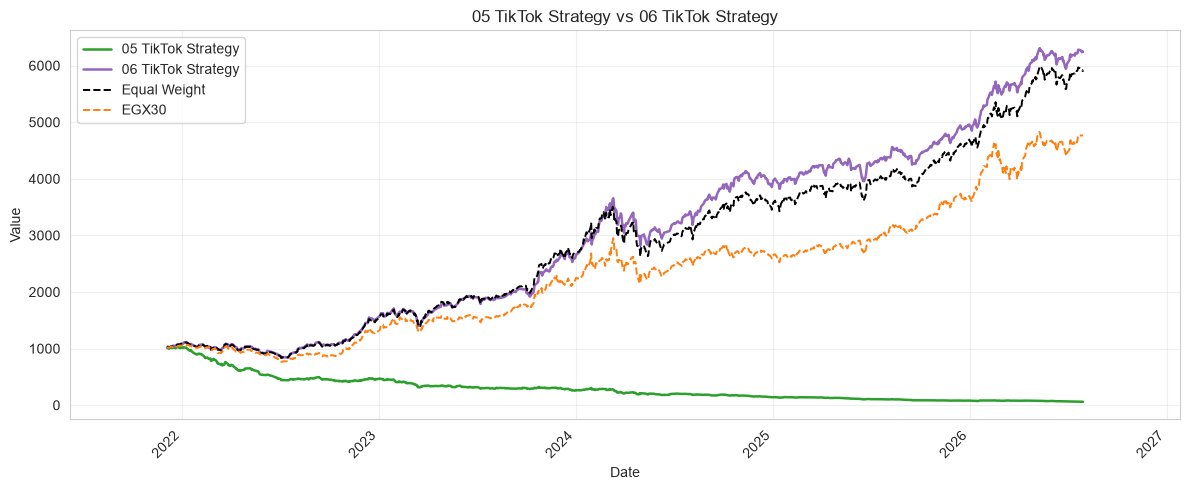

In [55]:
# Plot 2: Week 1 TikTok strategies
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(comparison_df['date'], comparison_df['tiktok_05'], label='05 TikTok Strategy', color='tab:green', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['tiktok'], label='06 TikTok Strategy', color='tab:purple', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['equal_weight'], label='Equal Weight', color='black', linewidth=1.4, linestyle='--')
ax.plot(comparison_df['date'], comparison_df['egx30'], label='EGX30', color='tab:orange', linewidth=1.4, linestyle='--')
ax.set_title('05 TikTok Strategy vs 06 TikTok Strategy')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.set_xlim(comparison_df['date'].min() - pd.Timedelta(days=180), comparison_df['date'].max() + pd.Timedelta(days=180))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

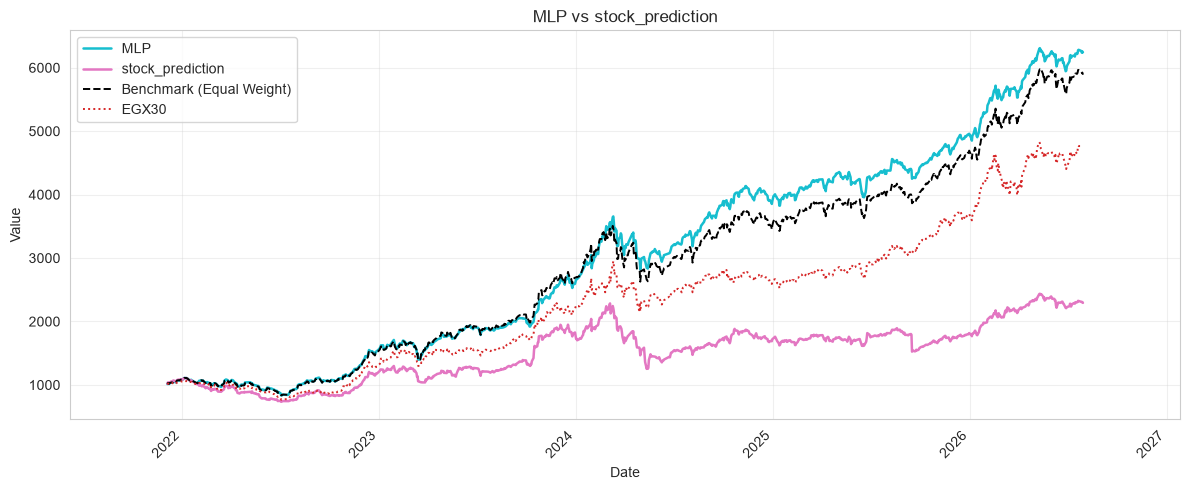

In [56]:
# Plot 3: MLP vs stock_prediction
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(comparison_df['date'], comparison_df['tiktok'], label='MLP', color='tab:cyan', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['sma'], label='stock_prediction', color='tab:pink', linewidth=1.8)
ax.plot(comparison_df['date'], comparison_df['equal_weight'], label='Benchmark (Equal Weight)', color='black', linewidth=1.4, linestyle='--')
ax.plot(comparison_df['date'], comparison_df['egx30'], label='EGX30', color='tab:red', linewidth=1.4, linestyle=':')
ax.set_title('MLP vs stock_prediction')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.set_xlim(comparison_df['date'].min() - pd.Timedelta(days=180), comparison_df['date'].max() + pd.Timedelta(days=180))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()